#### Imports

In [43]:
import stim
import pymatching
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree
from torch_geometric.loader import DataLoader
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
import os
import time
import json
import glob

# Import model classes and utilities from models.py
from models import (
    # STIM & MWPM utilities
    surface_code_circuit,
    count_logical_errors,
    ler_mwpm,
    plot_mwpm,
    # Surface Code Sampler
    SurfaceCodeSampler,
    # Sparse Graph
    SparseGraph,
    visualize_sparse_graph,
    # GCN Model
    GCNModel,
    GCN,
    # GAT Model
    GATModel,
    GAT,
    # GIN Model
    GINModel,
    GIN,
    # GraphSAGE Model
    GraphSAGEModel,
    GraphSAGE,
)

In [44]:
# If CUDA is available, show more details
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("PyTorch is using CPU only")

PyTorch is using CPU only


In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


#### Configuration

In [ ]:
# =============================================================================
# COMPARISON CONFIGURATION
# =============================================================================

# Model types to compare
MODEL_TYPES = ["gcn", "gat", "gin", "gsage"]

# Seeds for each model (1-5 for all types)
SEEDS = [1, 2, 3, 4, 5]

# Code distance to test
DISTANCE = 7

# Physical error rates for testing
P_VALUES = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008]

# Number of samples per error rate for accuracy testing
SAMPLES_PER_P = 5000

# Batch size for inference
BATCH_SIZE = 64

# Number of warmup and timing runs for benchmarking
NUM_WARMUP = 3
NUM_RUNS = 5

# Base path for models
MODELS_BASE_PATH = Path("models")

print("Configuration loaded:")
print(f"  Model types: {MODEL_TYPES}")
print(f"  Seeds: {SEEDS}")
print(f"  Distance: {DISTANCE}")
print(f"  P values: {P_VALUES}")
print(f"  Samples per p: {SAMPLES_PER_P}")

Configuration loaded:
  Model types: ['gcn', 'gat', 'gin', 'gsage']
  Seeds: [1, 2, 3, 4, 5]
  Distance: 3
  P values: [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008]
  Samples per p: 5000


### Initializations

#### Helper Functions

In [47]:
def get_model_class(model_type: str):
    """
    Return the appropriate model class for the given type.
    
    Args:
        model_type: One of "gcn", "gat", "gin", "gsage"
        
    Returns:
        The model wrapper class (GCN, GAT, GIN, or GraphSAGE)
    """
    model_classes = {
        "gcn": GCN,
        "gat": GAT,
        "gin": GIN,
        "gsage": GraphSAGE,
    }
    if model_type not in model_classes:
        raise ValueError(f"Unknown model type: {model_type}. Must be one of {list(model_classes.keys())}")
    return model_classes[model_type]


def load_model(model_type: str, filepath: str, device: torch.device):
    """
    Load any model type from file.
    
    Args:
        model_type: One of "gcn", "gat", "gin", "gsage"
        filepath: Path to the model file
        device: Torch device to load model on
        
    Returns:
        Loaded model instance
    """
    model_class = get_model_class(model_type)
    model = model_class(device=device)
    model.load(filepath)
    return model


def get_model_files(model_type: str, distance: int, seeds: list, base_path: Path = None) -> dict:
    """
    Get list of model file paths for given type/distance/seeds.
    
    Args:
        model_type: One of "gcn", "gat", "gin", "gsage"
        distance: Code distance (e.g., 3, 5, 7)
        seeds: List of seed numbers to look for
        base_path: Base path for models directory
        
    Returns:
        Dict mapping seed number to file path
    """
    if base_path is None:
        base_path = Path("models")
    
    model_dir = base_path / model_type
    model_files = {}
    
    for seed in seeds:
        # Pattern: d{distance}_baseline_seed_{seed}_*.pt
        pattern = f"d{distance}_baseline_seed_{seed}_*.pt"
        matches = list(model_dir.glob(pattern))
        
        if matches:
            # Use the most recent if multiple matches
            model_files[seed] = str(sorted(matches)[-1])
        else:
            print(f"Warning: No model found for {model_type} d{distance} seed {seed}")
    
    return model_files


def get_model_display_name(model_type: str) -> str:
    """Get human-readable name for model type."""
    names = {
        "gcn": "GCN",
        "gat": "GAT", 
        "gin": "GIN",
        "gsage": "GraphSAGE",
        "mwpm": "MWPM",
    }
    return names.get(model_type, model_type.upper())

#### Testing Functions

In [48]:
def generate_test_dataset(
    d: int,
    p_values: list,
    samples_per_p: int,
    device: torch.device = None,
    verbose: bool = True
) -> dict:
    """
    Generate a fixed test dataset to use for all model comparisons.
    
    This ensures all models are tested on exactly the same data for fair comparison.
    
    Args:
        d: Code distance
        p_values: List of physical error rates
        samples_per_p: Number of samples per error rate
        device: Torch device (defaults to CPU for generation)
        verbose: Print progress
        
    Returns:
        Dict containing:
            - 'graphs': List of PyG graph objects
            - 'labels': Tensor of labels
            - 'p_indices': Tensor indicating which p each sample came from
            - 'raw_detections': Raw detection tensor (for MWPM comparison)
            - 'p_values': List of p values used
            - 'd': Code distance
            - 'num_samples': Total number of samples
    """
    if device is None:
        device = torch.device('cpu')
    
    total_samples = samples_per_p * len(p_values)
    p_weights = [1.0 / len(p_values)] * len(p_values)
    
    if verbose:
        print(f"Generating test dataset: d={d}, {len(p_values)} error rates, {samples_per_p} samples each")
        print(f"Total samples: {total_samples:,}")
    
    # Generate on CPU for consistency
    sampler = SurfaceCodeSampler(p=p_values[0], device=torch.device('cpu'))
    graph_builder = SparseGraph(k_neighbors=6, device=torch.device('cpu'))
    
    # Sample detections
    detections, labels, p_indices = sampler.sample(
        d=d,
        num_samples=total_samples,
        p_values=p_values,
        p_weights=p_weights,
        return_p_labels=True
    )
    
    # Convert to graphs
    if verbose:
        print("Converting to PyG graphs...")
    graphs = graph_builder.batch_to_pyg(detections, labels)
    
    if verbose:
        print(f"Dataset ready: {len(graphs):,} graphs")
    
    return {
        'graphs': graphs,
        'labels': labels.cpu(),
        'p_indices': p_indices.cpu(),
        'raw_detections': detections.cpu(),
        'p_values': p_values,
        'd': d,
        'num_samples': total_samples,
        'samples_per_p': samples_per_p,
    }


def test_model_on_dataset(
    model,
    test_data: dict,
    threshold: float = 0.5,
    batch_size: int = 64,
    verbose: bool = False
) -> dict:
    """
    Test a model on a pre-generated dataset.
    
    Args:
        model: Trained model instance (GCN, GAT, GIN, or GraphSAGE)
        test_data: Dict from generate_test_dataset()
        threshold: Classification threshold (default 0.5)
        batch_size: Batch size for inference
        verbose: Print results
        
    Returns:
        Dictionary containing accuracy metrics
    """
    model_device = model.device
    model.model.eval()
    
    graphs = test_data['graphs']
    labels_cpu = test_data['labels']
    p_indices = test_data['p_indices']
    p_values = test_data['p_values']
    num_samples = test_data['num_samples']
    
    # Run predictions in batches
    all_preds = []
    
    with torch.no_grad():
        for i in range(0, len(graphs), batch_size):
            batch = Batch.from_data_list(graphs[i:i+batch_size])
            batch = batch.to(model_device)
            pred = model.model(batch)
            all_preds.append(pred.cpu())
    
    # Combine predictions
    predictions = torch.cat(all_preds, dim=0).squeeze()
    binary_preds = (predictions >= threshold).float()
    
    # Calculate metrics
    correct = (binary_preds == labels_cpu).sum().item()
    accuracy = correct / num_samples
    
    # True positives, false positives, etc.
    tp = ((binary_preds == 1) & (labels_cpu == 1)).sum().item()
    fp = ((binary_preds == 1) & (labels_cpu == 0)).sum().item()
    fn = ((binary_preds == 0) & (labels_cpu == 1)).sum().item()
    tn = ((binary_preds == 0) & (labels_cpu == 0)).sum().item()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    results = {
        'num_samples': num_samples,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'true_positives': tp,
        'false_positives': fp,
        'false_negatives': fn,
        'true_negatives': tn,
        'logical_error_rate': 1.0 - accuracy,
        'positive_rate': (tp + fn) / num_samples,
    }
    
    # Per-error-rate breakdown
    per_p_accuracy = {}
    per_p_ler = {}
    
    for i, p in enumerate(p_values):
        mask = (p_indices == i)
        if mask.sum() > 0:
            total_p = mask.sum().item()
            correct_p = (binary_preds[mask] == labels_cpu[mask]).sum().item()
            per_p_accuracy[p] = correct_p / total_p
            per_p_ler[p] = 1.0 - per_p_accuracy[p]
    
    results['per_p_accuracy'] = per_p_accuracy
    results['per_p_ler'] = per_p_ler
    
    if verbose:
        print(f"  Accuracy: {accuracy:.4f}, LER: {results['logical_error_rate']:.4f}")
    
    return results


def compute_mwpm_on_dataset(test_data: dict, verbose: bool = True) -> dict:
    """
    Compute MWPM decoder results on the SAME dataset used for GNN testing.
    
    This uses the actual detection events from the test dataset to ensure
    a fair comparison with the GNN models.
    
    Args:
        test_data: Dict from generate_test_dataset()
        verbose: Print progress
        
    Returns:
        Dict with MWPM results per error rate
    """
    d = test_data['d']
    p_values = test_data['p_values']
    p_indices = test_data['p_indices']
    labels_cpu = test_data['labels']
    raw_detections = test_data['raw_detections']
    num_samples = test_data['num_samples']
    
    if verbose:
        print("Computing MWPM on the same test dataset...")
    
    # Convert detections back to numpy format for MWPM
    # Detections are stored as -1/+1, need to convert to 0/1
    detections_numpy = ((raw_detections.numpy() + 1) / 2).astype(np.uint8)
    
    per_p_ler = {}
    per_p_err = {}
    total_errors = 0
    
    sampler = SurfaceCodeSampler(p=p_values[0], device=torch.device('cpu'))
    
    for i, p in enumerate(p_values):
        mask = (p_indices == i).numpy()
        if mask.sum() > 0:
            # Get detections for this p
            p_detections = detections_numpy[mask]
            p_labels = labels_cpu[mask].numpy()
            total_p = mask.sum()
            
            # Setup MWPM decoder for this p
            circuit = sampler._get_circuit(d, p)
            detector_error_model = circuit.detector_error_model(decompose_errors=True)
            matcher = pymatching.Matching.from_detector_error_model(detector_error_model)
            
            # Decode
            predictions = matcher.decode_batch(p_detections)
            
            # Count errors
            errors = np.sum(predictions.flatten() != p_labels)
            per_p_ler[p] = errors / total_p
            per_p_err[p] = np.sqrt(per_p_ler[p] * (1 - per_p_ler[p]) / total_p)
            total_errors += errors
            
            if verbose:
                print(f"  p={p:.4f}: LER={per_p_ler[p]:.4f}")
    
    overall_ler = total_errors / num_samples
    
    return {
        'per_p_ler': per_p_ler,
        'per_p_err': per_p_err,
        'overall_ler': overall_ler,
        'overall_accuracy': 1.0 - overall_ler,
    }

In [49]:
def evaluate_model_seeds(
    model_type: str,
    model_files: dict,
    test_data: dict,
    device: torch.device,
    verbose: bool = True
) -> dict:
    """
    Evaluate multiple seeds of a model on a SHARED dataset.
    
    All seeds are tested on exactly the same data for fair comparison.
    
    Args:
        model_type: One of "gcn", "gat", "gin", "gsage"
        model_files: Dict mapping seed number to file path
        test_data: Pre-generated test dataset from generate_test_dataset()
        device: Torch device
        verbose: Print progress
        
    Returns:
        Dict with per-seed results and aggregated mean/std metrics
    """
    p_values = test_data['p_values']
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"Evaluating {get_model_display_name(model_type)} with {len(model_files)} seeds")
        print(f"{'='*60}")
    
    # Store results for each seed
    seed_results = {}
    per_p_lers_all = {p: [] for p in p_values}
    
    for seed, filepath in sorted(model_files.items()):
        if verbose:
            print(f"\n  Testing seed {seed}: {Path(filepath).name}")
        
        # Load model
        model = load_model(model_type, filepath, device)
        
        # Test model on the SHARED dataset
        results = test_model_on_dataset(
            model=model,
            test_data=test_data,
            verbose=False
        )
        
        seed_results[seed] = results
        
        # Collect per-p LERs
        for p in p_values:
            if p in results['per_p_ler']:
                per_p_lers_all[p].append(results['per_p_ler'][p])
        
        if verbose:
            print(f"    Accuracy: {results['accuracy']:.4f}, LER: {results['logical_error_rate']:.4f}")
    
    # Calculate aggregated statistics
    accuracies = [r['accuracy'] for r in seed_results.values()]
    lers = [r['logical_error_rate'] for r in seed_results.values()]
    
    # Per-p mean and std
    per_p_mean_ler = {}
    per_p_std_ler = {}
    for p in p_values:
        if per_p_lers_all[p]:
            per_p_mean_ler[p] = np.mean(per_p_lers_all[p])
            per_p_std_ler[p] = np.std(per_p_lers_all[p])
    
    aggregated = {
        'model_type': model_type,
        'num_seeds': len(model_files),
        'seed_results': seed_results,
        'accuracies': accuracies,
        'mean_accuracy': np.mean(accuracies),
        'std_accuracy': np.std(accuracies),
        'logical_error_rates': lers,
        'mean_ler': np.mean(lers),
        'std_ler': np.std(lers),
        'per_p_mean_ler': per_p_mean_ler,
        'per_p_std_ler': per_p_std_ler,
    }
    
    if verbose:
        print(f"\n  Summary for {get_model_display_name(model_type)}:")
        print(f"    Mean Accuracy: {aggregated['mean_accuracy']:.4f} ± {aggregated['std_accuracy']:.4f}")
        print(f"    Mean LER: {aggregated['mean_ler']:.4f} ± {aggregated['std_ler']:.4f}")
    
    return aggregated

In [50]:
def compare_all_models(
    model_types: list,
    distance: int,
    seeds: list,
    p_values: list,
    samples_per_p: int,
    device: torch.device,
    base_path: Path = None,
    verbose: bool = True
) -> dict:
    """
    Compare all model types with mean/std from multiple seeds.
    
    IMPORTANT: All models are tested on the SAME dataset for fair comparison.
    The dataset is generated once and reused for all models and MWPM.
    
    Args:
        model_types: List of model types to compare
        distance: Code distance
        seeds: List of seed numbers
        p_values: List of physical error rates
        samples_per_p: Number of samples per error rate
        device: Torch device
        base_path: Base path for models
        verbose: Print progress
        
    Returns:
        Comprehensive comparison dict with all models + MWPM baseline
    """
    if verbose:
        print("=" * 70)
        print(f"COMPARING ALL MODELS FOR DISTANCE {distance}")
        print("=" * 70)
        print(f"Model types: {model_types}")
        print(f"Seeds: {seeds}")
        print(f"Error rates: {p_values}")
        print(f"Samples per p: {samples_per_p}")
    
    # ==========================================================================
    # GENERATE DATASET ONCE - All models will be tested on this same data
    # ==========================================================================
    if verbose:
        print("\n" + "-" * 70)
        print("GENERATING SHARED TEST DATASET")
        print("-" * 70)
    
    test_data = generate_test_dataset(
        d=distance,
        p_values=p_values,
        samples_per_p=samples_per_p,
        device=device,
        verbose=verbose
    )
    
    results = {
        'distance': distance,
        'p_values': p_values,
        'samples_per_p': samples_per_p,
        'num_samples': test_data['num_samples'],
        'models': {},
    }
    
    # ==========================================================================
    # EVALUATE ALL MODELS ON THE SAME DATASET
    # ==========================================================================
    if verbose:
        print("\n" + "-" * 70)
        print("EVALUATING MODELS ON SHARED DATASET")
        print("-" * 70)
    
    for model_type in model_types:
        model_files = get_model_files(model_type, distance, seeds, base_path)
        
        if not model_files:
            print(f"Warning: No models found for {model_type}")
            continue
        
        model_results = evaluate_model_seeds(
            model_type=model_type,
            model_files=model_files,
            test_data=test_data,
            device=device,
            verbose=verbose
        )
        
        results['models'][model_type] = model_results
    
    # ==========================================================================
    # COMPUTE MWPM ON THE SAME DATASET
    # ==========================================================================
    if verbose:
        print("\n" + "-" * 70)
        print("COMPUTING MWPM ON SAME DATASET")
        print("-" * 70)
    
    results['mwpm'] = compute_mwpm_on_dataset(test_data, verbose=verbose)
    
    # ==========================================================================
    # PRINT SUMMARY TABLE
    # ==========================================================================
    if verbose:
        print("\n" + "=" * 70)
        print("SUMMARY: Mean Logical Error Rate by Model (on SAME dataset)")
        print("=" * 70)
        print(f"{'Model':<15} {'Mean LER':<15} {'Std LER':<15} {'vs MWPM':<15}")
        print("-" * 70)
        
        # Get overall MWPM LER from the same dataset
        mwpm_overall_ler = results['mwpm']['overall_ler']
        
        for model_type, model_results in results['models'].items():
            name = get_model_display_name(model_type)
            mean_ler = model_results['mean_ler']
            std_ler = model_results['std_ler']
            diff = mean_ler - mwpm_overall_ler
            print(f"{name:<15} {mean_ler:.4f}          {std_ler:.4f}          {diff:+.4f}")
        
        print(f"{'MWPM':<15} {mwpm_overall_ler:.4f}          {'N/A':<15} {'baseline':<15}")
        print("=" * 70)
    
    return results

#### Plotting Functions

In [65]:
def plot_ler_comparison_multi(
    results: dict,
    save_path: str = None,
    figsize: tuple = (12, 8)
):
    """
    Plot LER curves for all models + MWPM with error bars.
    
    Args:
        results: Dict from compare_all_models()
        save_path: Optional path to save the figure
        figsize: Figure size tuple
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    p_values = results['p_values']
    distance = results['distance']
    
    # Define colors and markers for each model type
    styles = {
        'gcn': {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-'},
        'gat': {'color': '#ff7f0e', 'marker': 's', 'linestyle': '-'},
        'gin': {'color': '#2ca02c', 'marker': '^', 'linestyle': '-'},
        'gsage': {'color': '#d62728', 'marker': 'D', 'linestyle': '-'},
        'mwpm': {'color': '#9467bd', 'marker': 'x', 'linestyle': '--'},
    }
    
    # Plot each model's LER curve
    for model_type, model_results in results['models'].items():
        style = styles.get(model_type, {'color': 'gray', 'marker': 'o', 'linestyle': '-'})
        
        lers = [model_results['per_p_mean_ler'].get(p, np.nan) for p in p_values]
        errs = [model_results['per_p_std_ler'].get(p, 0) for p in p_values]
        
        ax.errorbar(
            p_values, lers, yerr=errs,
            label=get_model_display_name(model_type),
            color=style['color'],
            marker=style['marker'],
            linestyle=style['linestyle'],
            capsize=3,
            markersize=8,
            linewidth=2
        )
    
    # Plot MWPM baseline
    mwpm_data = results['mwpm']
    mwpm_lers = [mwpm_data['per_p_ler'].get(p, np.nan) for p in p_values]
    mwpm_errs = [mwpm_data['per_p_err'].get(p, 0) for p in p_values]
    
    style = styles['mwpm']
    ax.errorbar(
        p_values, mwpm_lers, yerr=mwpm_errs,
        label='MWPM',
        color=style['color'],
        marker=style['marker'],
        linestyle=style['linestyle'],
        capsize=3,
        markersize=8,
        linewidth=2
    )
    
    ax.set_xlabel('Physical Error Rate (p)', fontsize=12)
    ax.set_ylabel('Logical Error Rate (LER)', fontsize=12)
    ax.set_title(f'GNN Decoder Comparison vs MWPM (d={distance})', fontsize=14)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()
    
    return fig


def plot_accuracy_comparison_bar(
    results: dict,
    save_path: str = None,
    figsize: tuple = (14, 5)
):
    """
    Bar chart comparing mean accuracy with error bars for all models.
    Shows two views: full range (0 to 1) and zoomed view.
    
    Args:
        results: Dict from compare_all_models()
        save_path: Optional path to save the figure
        figsize: Figure size tuple
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    model_names = []
    accuracies = []
    errors = []
    colors = []
    
    color_map = {
        'gcn': '#1f77b4',
        'gat': '#ff7f0e',
        'gin': '#2ca02c',
        'gsage': '#d62728',
    }
    
    for model_type, model_results in results['models'].items():
        model_names.append(get_model_display_name(model_type))
        accuracies.append(model_results['mean_accuracy'])
        errors.append(model_results['std_accuracy'])
        colors.append(color_map.get(model_type, 'gray'))
    
    # Add MWPM
    mwpm_ler = np.mean(list(results['mwpm']['per_p_ler'].values()))
    mwpm_acc = 1.0 - mwpm_ler
    model_names.append('MWPM')
    accuracies.append(mwpm_acc)
    errors.append(0)  # No std for single MWPM run
    colors.append('#9467bd')
    
    x = np.arange(len(model_names))
    
    # Left plot: Full range (0 to 1)
    bars1 = ax1.bar(x, accuracies, yerr=errors, capsize=5, color=colors, edgecolor='black', linewidth=1.5)
    ax1.set_xlabel('Model', fontsize=12)
    ax1.set_ylabel('Mean Accuracy', fontsize=12)
    ax1.set_title(f'Full Range (d={results["distance"]})', fontsize=14)
    ax1.set_xticks(x)
    ax1.set_xticklabels(model_names, fontsize=11)
    ax1.set_ylim(0, 1.0)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars (full range)
    for bar, acc in zip(bars1, accuracies):
        height = bar.get_height()
        ax1.annotate(f'{acc:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)
    
    # Right plot: Zoomed view (dynamic range based on data)
    min_acc = min(accuracies) - max(errors) if errors else min(accuracies)
    max_acc = max(accuracies) + max(errors) if errors else max(accuracies)
    # Add some padding and ensure all bars are visible
    y_min = max(0, min_acc - 0.02)
    y_max = min(1.0, max_acc + 0.02)
    
    bars2 = ax2.bar(x, accuracies, yerr=errors, capsize=5, color=colors, edgecolor='black', linewidth=1.5)
    ax2.set_xlabel('Model', fontsize=12)
    ax2.set_ylabel('Mean Accuracy', fontsize=12)
    ax2.set_title(f'Zoomed View (d={results["distance"]})', fontsize=14)
    ax2.set_xticks(x)
    ax2.set_xticklabels(model_names, fontsize=11)
    ax2.set_ylim(y_min, y_max)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars (zoomed)
    for bar, acc in zip(bars2, accuracies):
        height = bar.get_height()
        ax2.annotate(f'{acc:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)
    
    plt.suptitle(f'Model Accuracy Comparison', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()
    
    return fig

#### Inference Speed Benchmarking

In [52]:
def benchmark_single_model(
    model,
    graphs: list,
    batch_size: int,
    num_warmup: int,
    num_runs: int,
    device: torch.device
) -> dict:
    """
    Benchmark inference speed for a single model.
    
    Args:
        model: Model instance
        graphs: List of PyG graphs to run inference on
        batch_size: Batch size for inference
        num_warmup: Number of warmup batches
        num_runs: Number of timed runs
        device: Torch device
        
    Returns:
        Dict with timing results
    """
    model.model.eval()
    model.model.to(device)
    
    # Move graphs to device
    graphs_on_device = [g.to(device) for g in graphs]
    loader = DataLoader(graphs_on_device, batch_size=batch_size, shuffle=False)
    num_samples = len(graphs)
    
    # Warmup
    with torch.no_grad():
        warmup_count = 0
        for batch in loader:
            if warmup_count >= num_warmup:
                break
            _ = model.model(batch)
            warmup_count += 1
    
    if device.type == 'cuda':
        torch.cuda.synchronize()
    
    # Timed runs
    run_times = []
    for _ in range(num_runs):
        if device.type == 'cuda':
            torch.cuda.synchronize()
        
        start = time.perf_counter()
        with torch.no_grad():
            for batch in loader:
                _ = model.model(batch)
        
        if device.type == 'cuda':
            torch.cuda.synchronize()
        
        elapsed = time.perf_counter() - start
        run_times.append(elapsed)
    
    avg_time = np.mean(run_times)
    std_time = np.std(run_times)
    throughput = num_samples / avg_time
    latency_ms = (avg_time / num_samples) * 1000
    
    return {
        'total_time_sec': avg_time,
        'total_time_std': std_time,
        'throughput_graphs_per_sec': throughput,
        'latency_ms_per_graph': latency_ms,
    }


def benchmark_mwpm_on_data(
    d: int,
    p: float,
    raw_detections: np.ndarray,
    num_runs: int
) -> dict:
    """
    Benchmark MWPM decoder speed on pre-generated detection events.
    
    Uses the SAME detections that were used for GNN benchmarking.
    
    Args:
        d: Code distance
        p: Physical error rate (for decoder setup)
        raw_detections: Pre-generated detection events (numpy array, 0/1 format)
        num_runs: Number of timed runs
        
    Returns:
        Dict with timing results
    """
    num_samples = raw_detections.shape[0]
    
    # Setup MWPM decoder
    sampler = SurfaceCodeSampler(p=p, device=torch.device('cpu'))
    circuit = sampler._get_circuit(d, p)
    detector_error_model = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(detector_error_model)
    
    # Warmup
    _ = matcher.decode_batch(raw_detections[:64])
    
    # Timed runs
    run_times = []
    for _ in range(num_runs):
        start = time.perf_counter()
        _ = matcher.decode_batch(raw_detections)
        elapsed = time.perf_counter() - start
        run_times.append(elapsed)
    
    avg_time = np.mean(run_times)
    std_time = np.std(run_times)
    throughput = num_samples / avg_time
    latency_ms = (avg_time / num_samples) * 1000
    
    return {
        'total_time_sec': avg_time,
        'total_time_std': std_time,
        'throughput_graphs_per_sec': throughput,
        'latency_ms_per_graph': latency_ms,
    }


def benchmark_model_seeds(
    model_type: str,
    model_files: dict,
    graphs: list,
    batch_size: int,
    num_warmup: int,
    num_runs: int,
    device: torch.device,
    verbose: bool = True
) -> dict:
    """
    Benchmark inference speed across multiple seeds.
    
    Args:
        model_type: One of "gcn", "gat", "gin", "gsage"
        model_files: Dict mapping seed number to file path
        graphs: List of PyG graphs
        batch_size: Batch size for inference
        num_warmup: Number of warmup batches
        num_runs: Number of timed runs
        device: Torch device
        verbose: Print progress
        
    Returns:
        Dict with per-seed and aggregated results
    """
    if verbose:
        print(f"\n  Benchmarking {get_model_display_name(model_type)} ({len(model_files)} seeds)...")
    
    seed_results = {}
    throughputs = []
    latencies = []
    
    for seed, filepath in sorted(model_files.items()):
        model = load_model(model_type, filepath, device)
        
        result = benchmark_single_model(
            model=model,
            graphs=graphs,
            batch_size=batch_size,
            num_warmup=num_warmup,
            num_runs=num_runs,
            device=device
        )
        
        seed_results[seed] = result
        throughputs.append(result['throughput_graphs_per_sec'])
        latencies.append(result['latency_ms_per_graph'])
        
        if verbose:
            print(f"    Seed {seed}: {result['throughput_graphs_per_sec']:.1f} graphs/sec")
    
    aggregated = {
        'model_type': model_type,
        'num_seeds': len(model_files),
        'seed_results': seed_results,
        'throughputs': throughputs,
        'mean_throughput': np.mean(throughputs),
        'std_throughput': np.std(throughputs),
        'latencies': latencies,
        'mean_latency': np.mean(latencies),
        'std_latency': np.std(latencies),
    }
    
    if verbose:
        print(f"    Mean: {aggregated['mean_throughput']:.1f} ± {aggregated['std_throughput']:.1f} graphs/sec")
    
    return aggregated


def compare_inference_speeds(
    model_types: list,
    distance: int,
    seeds: list,
    num_samples: int,
    batch_size: int,
    p: float,
    num_warmup: int,
    num_runs: int,
    device: torch.device,
    base_path: Path = None,
    verbose: bool = True
) -> dict:
    """
    Compare inference speeds with mean/std across seeds.
    
    IMPORTANT: All models AND MWPM are tested on the SAME dataset.
    
    Args:
        model_types: List of model types to compare
        distance: Code distance
        seeds: List of seed numbers
        num_samples: Number of samples for benchmarking
        batch_size: Batch size for inference
        p: Physical error rate for generating test data
        num_warmup: Number of warmup batches
        num_runs: Number of timed runs
        device: Torch device
        base_path: Base path for models
        verbose: Print progress
        
    Returns:
        Dict with inference speed comparison results
    """
    if verbose:
        print("=" * 70)
        print(f"INFERENCE SPEED COMPARISON (d={distance})")
        print("=" * 70)
        print(f"Samples: {num_samples:,} | Batch size: {batch_size}")
    
    # ==========================================================================
    # GENERATE SHARED DATA - Used for both GNN models AND MWPM
    # ==========================================================================
    if verbose:
        print(f"\nGenerating SHARED test data ({num_samples:,} samples)...")
    
    cpu_device = torch.device("cpu")
    sampler = SurfaceCodeSampler(p=p, device=cpu_device)
    graph_builder = SparseGraph(k_neighbors=6, device=cpu_device)
    
    detections, labels = sampler.sample(d=distance, num_samples=num_samples, p_values=[p], p_weights=[1.0])
    graphs = graph_builder.batch_to_pyg(detections, labels)
    
    # Convert detections to numpy format for MWPM (from -1/+1 to 0/1)
    raw_detections_numpy = ((detections.cpu().numpy() + 1) / 2).astype(np.uint8)
    
    if verbose:
        print(f"Generated {len(graphs):,} graphs (same data for all models)")
    
    results = {
        'distance': distance,
        'num_samples': num_samples,
        'batch_size': batch_size,
        'device': str(device),
        'models': {},
    }
    
    # ==========================================================================
    # BENCHMARK ALL GNN MODELS ON SHARED DATA
    # ==========================================================================
    for model_type in model_types:
        model_files = get_model_files(model_type, distance, seeds, base_path)
        
        if not model_files:
            print(f"Warning: No models found for {model_type}")
            continue
        
        model_results = benchmark_model_seeds(
            model_type=model_type,
            model_files=model_files,
            graphs=graphs,
            batch_size=batch_size,
            num_warmup=num_warmup,
            num_runs=num_runs,
            device=device,
            verbose=verbose
        )
        
        results['models'][model_type] = model_results
    
    # ==========================================================================
    # BENCHMARK MWPM ON SAME SHARED DATA
    # ==========================================================================
    if verbose:
        print(f"\n  Benchmarking MWPM (on SAME data)...")
    
    mwpm_result = benchmark_mwpm_on_data(
        d=distance,
        p=p,
        raw_detections=raw_detections_numpy,
        num_runs=num_runs
    )
    results['mwpm'] = mwpm_result
    
    if verbose:
        print(f"    MWPM: {mwpm_result['throughput_graphs_per_sec']:.1f} graphs/sec")
    
    # ==========================================================================
    # PRINT SUMMARY TABLE
    # ==========================================================================
    if verbose:
        print("\n" + "=" * 70)
        print("INFERENCE SPEED SUMMARY (all on SAME dataset)")
        print("=" * 70)
        print(f"{'Model':<15} {'Throughput (g/s)':<20} {'Latency (ms)':<15} {'vs MWPM':<15}")
        print("-" * 70)
        
        mwpm_tp = mwpm_result['throughput_graphs_per_sec']
        
        for model_type, model_results in results['models'].items():
            name = get_model_display_name(model_type)
            tp = model_results['mean_throughput']
            tp_std = model_results['std_throughput']
            lat = model_results['mean_latency']
            
            if tp > mwpm_tp:
                speedup = f"{tp/mwpm_tp:.2f}x faster"
            else:
                speedup = f"{mwpm_tp/tp:.2f}x slower"
            
            print(f"{name:<15} {tp:>8.1f} ± {tp_std:<8.1f} {lat:>8.4f} ms     {speedup:<15}")
        
        print(f"{'MWPM':<15} {mwpm_tp:>8.1f}            {mwpm_result['latency_ms_per_graph']:>8.4f} ms     {'baseline':<15}")
        print("=" * 70)
    
    return results


def plot_inference_comparison(
    results: dict,
    save_path: str = None,
    figsize: tuple = (12, 6)
):
    """
    Bar chart comparing inference speeds with error bars.
    
    Args:
        results: Dict from compare_inference_speeds()
        save_path: Optional path to save the figure
        figsize: Figure size tuple
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    model_names = []
    throughputs = []
    throughput_errs = []
    latencies = []
    latency_errs = []
    colors = []
    
    color_map = {
        'gcn': '#1f77b4',
        'gat': '#ff7f0e',
        'gin': '#2ca02c',
        'gsage': '#d62728',
    }
    
    for model_type, model_results in results['models'].items():
        model_names.append(get_model_display_name(model_type))
        throughputs.append(model_results['mean_throughput'])
        throughput_errs.append(model_results['std_throughput'])
        latencies.append(model_results['mean_latency'])
        latency_errs.append(model_results['std_latency'])
        colors.append(color_map.get(model_type, 'gray'))
    
    # Add MWPM
    model_names.append('MWPM')
    throughputs.append(results['mwpm']['throughput_graphs_per_sec'])
    throughput_errs.append(0)
    latencies.append(results['mwpm']['latency_ms_per_graph'])
    latency_errs.append(0)
    colors.append('#9467bd')
    
    x = np.arange(len(model_names))
    
    # Throughput plot
    ax1.bar(x, throughputs, yerr=throughput_errs, capsize=5, color=colors, edgecolor='black', linewidth=1.5)
    ax1.set_xlabel('Model', fontsize=12)
    ax1.set_ylabel('Throughput (graphs/sec)', fontsize=12)
    ax1.set_title('Inference Throughput Comparison', fontsize=14)
    ax1.set_xticks(x)
    ax1.set_xticklabels(model_names, fontsize=11)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Latency plot
    ax2.bar(x, latencies, yerr=latency_errs, capsize=5, color=colors, edgecolor='black', linewidth=1.5)
    ax2.set_xlabel('Model', fontsize=12)
    ax2.set_ylabel('Latency (ms/graph)', fontsize=12)
    ax2.set_title('Inference Latency Comparison', fontsize=14)
    ax2.set_xticks(x)
    ax2.set_xticklabels(model_names, fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'Inference Speed Comparison (d={results["distance"]})', fontsize=14, y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()
    
    return fig

---

### Benchmarking

This section runs all benchmark tests to collect accuracy and inference speed data.

Ensure the benchmarks directory exists for saving results:

In [53]:
# Create benchmarks directory if it doesn't exist
Path("benchmarks").mkdir(exist_ok=True)
print("Benchmarks directory ready.")

Benchmarks directory ready.


#### Accuracy Comparison (All Models vs MWPM)

In [54]:
# Run the full accuracy comparison across all models
accuracy_results = compare_all_models(
    model_types=MODEL_TYPES,
    distance=DISTANCE,
    seeds=SEEDS,
    p_values=P_VALUES,
    samples_per_p=SAMPLES_PER_P,
    device=device,
    base_path=MODELS_BASE_PATH,
    verbose=True
)

COMPARING ALL MODELS FOR DISTANCE 5
Model types: ['gcn', 'gat', 'gin', 'gsage']
Seeds: [1, 2, 3, 4, 5]
Error rates: [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008]
Samples per p: 5000

----------------------------------------------------------------------
GENERATING SHARED TEST DATASET
----------------------------------------------------------------------
Generating test dataset: d=5, 8 error rates, 5000 samples each
Total samples: 40,000
SurfaceCodeSampler initialized:
  Default error rate: 0.001
  Device: cpu
  Mode: Dynamic (supports any code distance)
SparseGraph initialized:
  K neighbors: 6
  Device: cpu
  Mode: Dynamic (supports any code distance)
Converting to PyG graphs...
Dataset ready: 40,000 graphs

----------------------------------------------------------------------
EVALUATING MODELS ON SHARED DATASET
----------------------------------------------------------------------

Evaluating GCN with 5 seeds

  Testing seed 1: d5_baseline_seed_1_2026-01-13_23-06-53.pt
GC

#### Inference Speed Comparison

In [55]:
# Run inference speed comparison across all models
speed_results = compare_inference_speeds(
    model_types=MODEL_TYPES,
    distance=DISTANCE,
    seeds=SEEDS,
    num_samples=10000,
    batch_size=BATCH_SIZE,
    p=0.005,
    num_warmup=NUM_WARMUP,
    num_runs=NUM_RUNS,
    device=device,
    base_path=MODELS_BASE_PATH,
    verbose=True
)

INFERENCE SPEED COMPARISON (d=5)
Samples: 10,000 | Batch size: 64

Generating SHARED test data (10,000 samples)...
SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cpu
  Mode: Dynamic (supports any code distance)
SparseGraph initialized:
  K neighbors: 6
  Device: cpu
  Mode: Dynamic (supports any code distance)
Generated 10,000 graphs (same data for all models)

  Benchmarking GCN (5 seeds)...
GCN initialized: GCN(nickname='gcn_model', in_channels=5, hidden_dim=128, num_layers=4)
Model loaded: GCN(nickname='d5_baseline_seed_1', in_channels=5, hidden_dim=128, num_layers=4, loaded_from='d5_baseline_seed_1_2026-01-13_23-06-53.pt')
    Seed 1: 5143.9 graphs/sec
GCN initialized: GCN(nickname='gcn_model', in_channels=5, hidden_dim=128, num_layers=4)
Model loaded: GCN(nickname='d5_baseline_seed_2', in_channels=5, hidden_dim=128, num_layers=4, loaded_from='d5_baseline_seed_2_2026-01-14_00-29-34.pt')
    Seed 2: 5090.0 graphs/sec
GCN initialized: GCN(nickname='gcn_model', 

###3 Export Summary Data to CSV

In [56]:
import pandas as pd
from datetime import datetime

def create_summary_dataframe(accuracy_results: dict, speed_results: dict) -> pd.DataFrame:
    """Create a pandas DataFrame with all summary statistics."""
    
    rows = []
    model_types = list(accuracy_results['models'].keys())
    p_values = accuracy_results['p_values']
    mwpm_tp = speed_results['mwpm']['throughput_graphs_per_sec']
    mwpm_ler = accuracy_results['mwpm']['overall_ler']
    
    for model_type in model_types:
        acc_results = accuracy_results['models'][model_type]
        spd_results = speed_results['models'][model_type]
        
        # Get average precision/recall/f1 from seed results
        precisions = [r['precision'] for r in acc_results['seed_results'].values()]
        recalls = [r['recall'] for r in acc_results['seed_results'].values()]
        f1s = [r['f1'] for r in acc_results['seed_results'].values()]
        
        row = {
            'model': get_model_display_name(model_type),
            'model_type': model_type,
            'mean_accuracy': acc_results['mean_accuracy'],
            'std_accuracy': acc_results['std_accuracy'],
            'mean_ler': acc_results['mean_ler'],
            'std_ler': acc_results['std_ler'],
            'mean_precision': np.mean(precisions),
            'mean_recall': np.mean(recalls),
            'mean_f1': np.mean(f1s),
            'mean_throughput': spd_results['mean_throughput'],
            'std_throughput': spd_results['std_throughput'],
            'mean_latency_ms': spd_results['mean_latency'],
            'std_latency_ms': spd_results['std_latency'],
            'speed_vs_mwpm_ratio': mwpm_tp / spd_results['mean_throughput'],
            'ler_vs_mwpm_diff': acc_results['mean_ler'] - mwpm_ler,
        }
        
        # Add per-p LER values
        for p in p_values:
            row[f'ler_p_{p:.3f}'] = acc_results['per_p_mean_ler'].get(p, np.nan)
        
        rows.append(row)
    
    # Add MWPM row
    mwpm_row = {
        'model': 'MWPM',
        'model_type': 'mwpm',
        'mean_accuracy': 1 - mwpm_ler,
        'std_accuracy': np.nan,
        'mean_ler': mwpm_ler,
        'std_ler': np.nan,
        'mean_precision': np.nan,
        'mean_recall': np.nan,
        'mean_f1': np.nan,
        'mean_throughput': mwpm_tp,
        'std_throughput': np.nan,
        'mean_latency_ms': speed_results['mwpm']['latency_ms_per_graph'],
        'std_latency_ms': np.nan,
        'speed_vs_mwpm_ratio': 1.0,
        'ler_vs_mwpm_diff': 0.0,
    }
    
    # Add per-p LER values for MWPM
    for p in p_values:
        mwpm_row[f'ler_p_{p:.3f}'] = accuracy_results['mwpm']['per_p_ler'].get(p, np.nan)
    
    rows.append(mwpm_row)
    
    return pd.DataFrame(rows)

# Create the summary DataFrame
summary_df = create_summary_dataframe(accuracy_results, speed_results)

# Save to CSV with timestamp
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
csv_path = f'benchmarks/test_summary_d{DISTANCE}_{timestamp}.csv'
summary_df.to_csv(csv_path, index=False)
print(f"Summary saved to: {csv_path}")

# Display the DataFrame
print("\nSummary DataFrame:")
summary_df

Summary saved to: benchmarks/test_summary_d5_2026-01-14_11-12-19.csv

Summary DataFrame:


,model,model_type,mean_accuracy,std_accuracy,mean_ler,std_ler,mean_precision,mean_recall,mean_f1,mean_throughput,...,speed_vs_mwpm_ratio,ler_vs_mwpm_diff,ler_p_0.001,ler_p_0.002,ler_p_0.003,ler_p_0.004,ler_p_0.005,ler_p_0.006,ler_p_0.007,ler_p_0.008
0,GCN,gcn,0.837705,0.000774,0.162295,0.000774,0.731431,0.323234,0.447731,5148.489429,...,72.553846,0.145520,0.02268,0.06760,0.11116,0.14040,0.18852,0.22528,0.26200,0.28072
1,GAT,gat,0.921180,0.004813,0.078820,0.004813,0.842242,0.755029,0.795790,4291.099578,...,87.050581,0.062045,0.00328,0.01528,0.03464,0.05732,0.08200,0.11056,0.14892,0.17856
2,GIN,gin,0.931930,0.020993,0.068070,0.020993,0.868343,0.782385,0.820697,5178.283472,...,72.136397,0.051295,0.00144,0.00928,0.02412,0.04304,0.07204,0.09588,0.13336,0.16540
3,GraphSAGE,gsage,0.952910,0.000859,0.047090,0.000859,0.907378,0.856477,0.881143,6632.071829,...,56.323683,0.030315,0.00024,0.00220,0.01068,0.02524,0.04604,0.06448,0.09704,0.13080
4,MWPM,mwpm,0.983225,NaN,0.016775,NaN,NaN,NaN,NaN,373542.710925,...,1.000000,0.000000,0.00000,0.00080,0.00380,0.00820,0.01360,0.02320,0.03440,0.05020


### Visualization

Load benchmark results and display visualizations.

In [69]:
# Load the latest benchmark summary CSV
import glob

# Find the most recent CSV file
csv_files = sorted(glob.glob(f'benchmarks/test_summary_d{DISTANCE}_*.csv'))
if csv_files:
    latest_csv = csv_files[-1]
    summary_df = pd.read_csv(latest_csv)
    print(f"Loaded benchmark data from: {latest_csv}")
    print(f"\nSummary DataFrame shape: {summary_df.shape}")
    display(summary_df)
else:
    print("No benchmark CSV files found. Run the benchmarking section first.")

Loaded benchmark data from: benchmarks/test_summary_d3_2026-01-14_11-00-50.csv

Summary DataFrame shape: (5, 23)


,model,model_type,mean_accuracy,std_accuracy,mean_ler,std_ler,mean_precision,mean_recall,mean_f1,mean_throughput,...,speed_vs_mwpm_ratio,ler_vs_mwpm_diff,ler_p_0.001,ler_p_0.002,ler_p_0.003,ler_p_0.004,ler_p_0.005,ler_p_0.006,ler_p_0.007,ler_p_0.008
0,GCN,gcn,0.961750,0.000323,0.038250,0.000323,0.854540,0.700137,0.769655,1.092618e+04,...,306.551502,0.022400,0.00108,0.00680,0.01780,0.02576,0.03948,0.05180,0.07108,0.09220
1,GAT,gat,0.982110,0.000404,0.017890,0.000404,0.934182,0.865023,0.898244,1.020963e+04,...,328.066709,0.002040,0.00052,0.00320,0.00648,0.01124,0.01612,0.02644,0.03612,0.04300
2,GIN,gin,0.981915,0.000762,0.018085,0.000762,0.933389,0.863654,0.897090,1.234142e+04,...,271.398195,0.002235,0.00060,0.00332,0.00672,0.01316,0.01540,0.02688,0.03472,0.04388
3,GraphSAGE,gsage,0.984050,0.000150,0.015950,0.000150,0.936703,0.885182,0.910155,1.305395e+04,...,256.584332,0.000100,0.00040,0.00288,0.00632,0.01104,0.01440,0.02288,0.03192,0.03776
4,MWPM,mwpm,0.984150,NaN,0.015850,NaN,NaN,NaN,NaN,3.349438e+06,...,1.000000,0.000000,0.00060,0.00340,0.00700,0.01080,0.01440,0.02200,0.03260,0.03600


Figure saved to: benchmarks/ler_comparison_d3.png


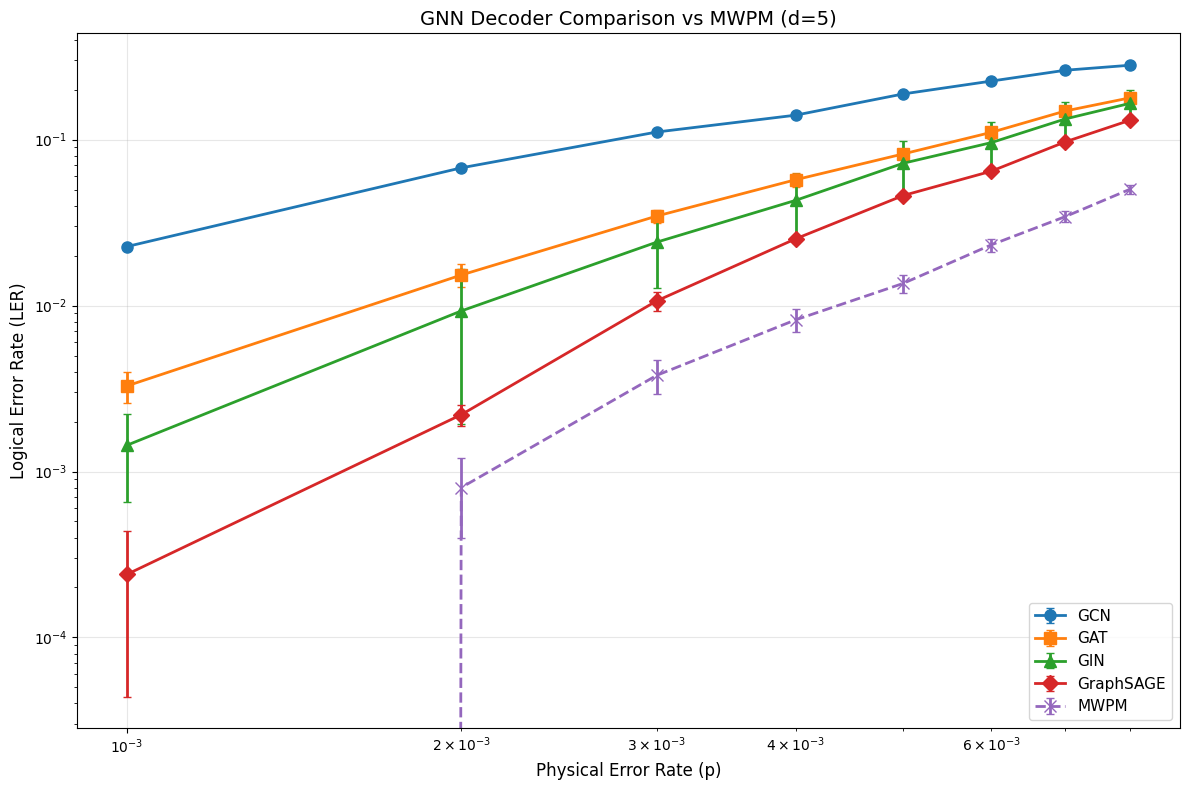

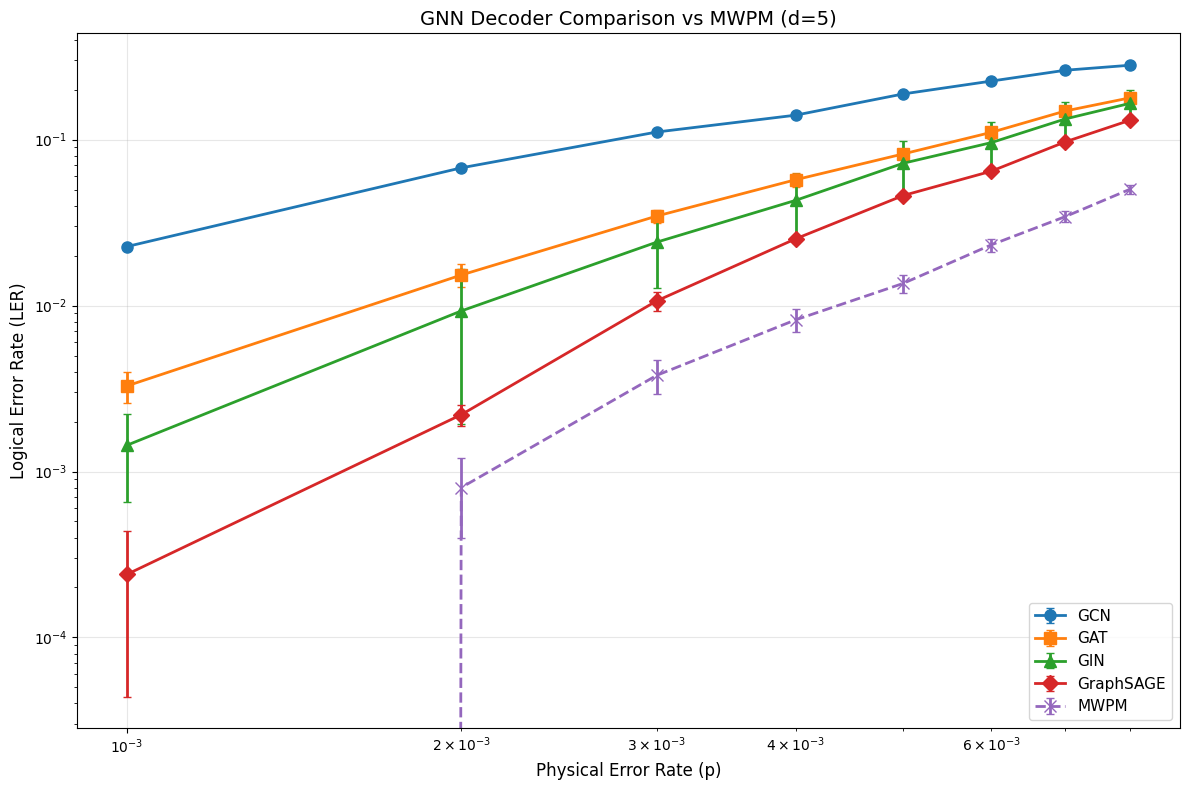

In [70]:
# Plot LER comparison (all models vs MWPM)
plot_ler_comparison_multi(
    results=accuracy_results,
    save_path=f"benchmarks/ler_comparison_d{DISTANCE}.png"
)

Figure saved to: benchmarks/accuracy_comparison_d3.png


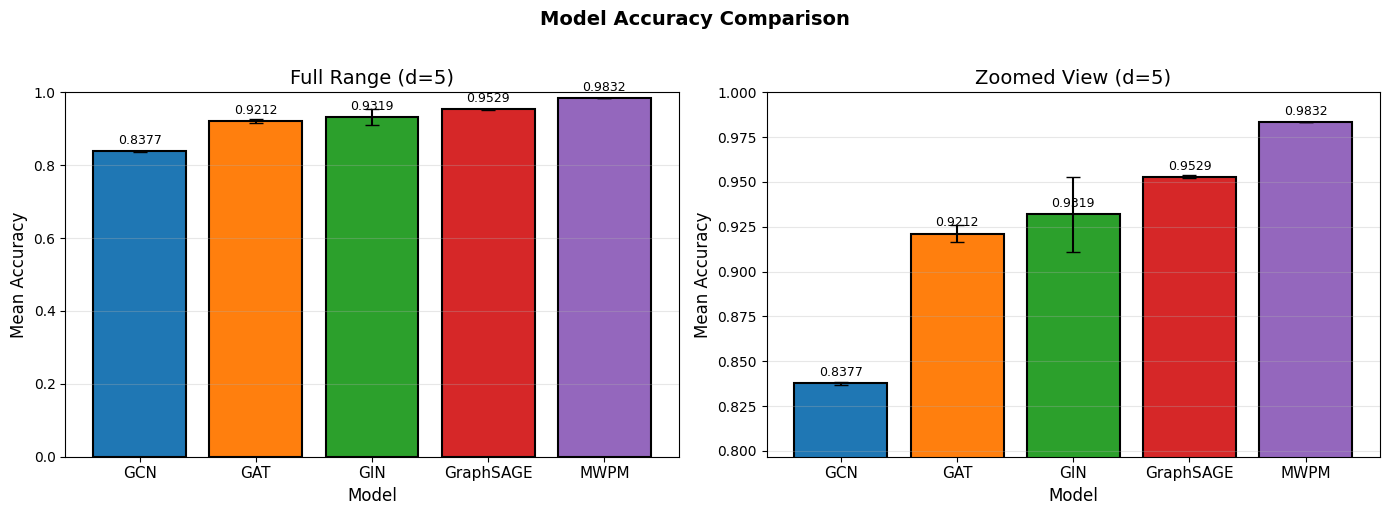

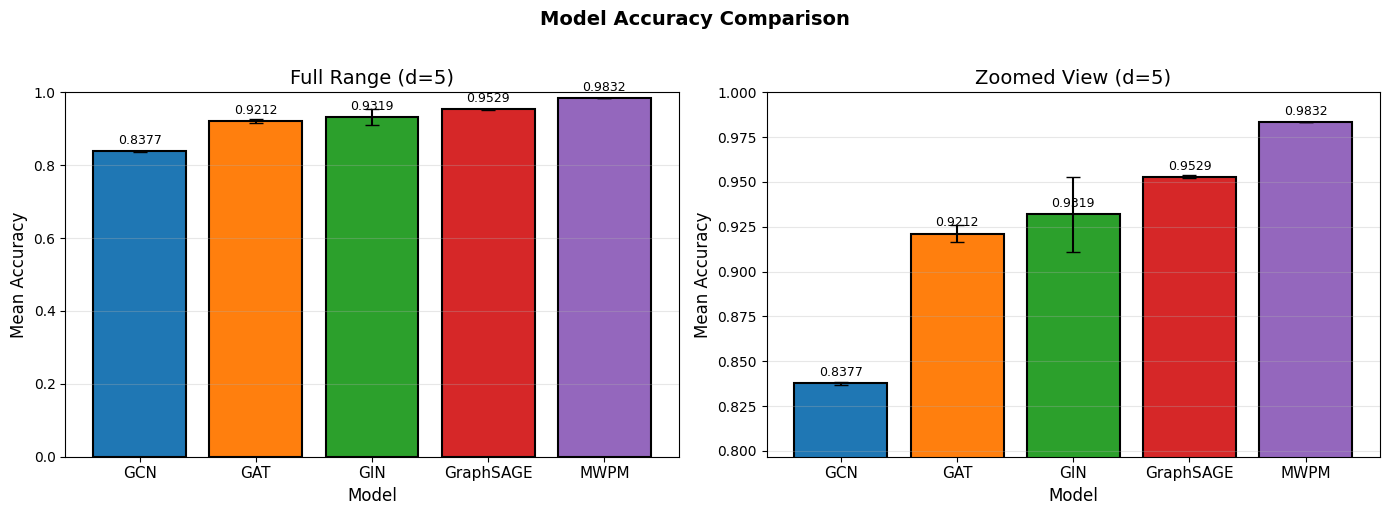

In [71]:
# Plot accuracy bar chart comparison
plot_accuracy_comparison_bar(
    results=accuracy_results,
    save_path=f"benchmarks/accuracy_comparison_d{DISTANCE}.png"
)

#### Accuracy Ranking

Rankings based on the accuracy comparison metrics (lower LER is better):

In [72]:
def print_accuracy_ranking(accuracy_results: dict):
    """Print model rankings based on accuracy metrics."""
    print("=" * 70)
    print("MODEL RANKINGS - ACCURACY COMPARISON")
    print("=" * 70)
    
    # Collect model data including MWPM
    model_data = []
    
    for model_type, results in accuracy_results['models'].items():
        model_data.append({
            'name': get_model_display_name(model_type),
            'mean_ler': results['mean_ler'],
            'std_ler': results['std_ler'],
            'mean_accuracy': results['mean_accuracy'],
            'std_accuracy': results['std_accuracy'],
        })
    
    # Add MWPM
    mwpm_ler = accuracy_results['mwpm']['overall_ler']
    model_data.append({
        'name': 'MWPM',
        'mean_ler': mwpm_ler,
        'std_ler': 0.0,
        'mean_accuracy': 1 - mwpm_ler,
        'std_accuracy': 0.0,
    })
    
    # Sort by mean LER (lower is better)
    ranked_by_ler = sorted(model_data, key=lambda x: x['mean_ler'])
    
    print("\n🏆 RANKING BY LOGICAL ERROR RATE (Lower is Better)")
    print("-" * 70)
    print(f"{'Rank':<6} {'Model':<15} {'Mean LER':<15} {'Std LER':<15}")
    print("-" * 70)
    for rank, model in enumerate(ranked_by_ler, 1):
        medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
        print(f"{medal} {rank:<3} {model['name']:<15} {model['mean_ler']:.6f}       {model['std_ler']:.6f}")
    
    # Sort by mean accuracy (higher is better)
    ranked_by_acc = sorted(model_data, key=lambda x: x['mean_accuracy'], reverse=True)
    
    print("\n🏆 RANKING BY ACCURACY (Higher is Better)")
    print("-" * 70)
    print(f"{'Rank':<6} {'Model':<15} {'Mean Accuracy':<15} {'Std Accuracy':<15}")
    print("-" * 70)
    for rank, model in enumerate(ranked_by_acc, 1):
        medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
        print(f"{medal} {rank:<3} {model['name']:<15} {model['mean_accuracy']:.6f}       {model['std_accuracy']:.6f}")
    
    print("=" * 70)
    
    return ranked_by_ler, ranked_by_acc

# Print accuracy rankings
ler_ranking, acc_ranking = print_accuracy_ranking(accuracy_results)

MODEL RANKINGS - ACCURACY COMPARISON

🏆 RANKING BY LOGICAL ERROR RATE (Lower is Better)
----------------------------------------------------------------------
Rank   Model           Mean LER        Std LER        
----------------------------------------------------------------------
🥇 1   MWPM            0.016775       0.000000
🥈 2   GraphSAGE       0.047090       0.000859
🥉 3   GIN             0.068070       0.020993
   4   GAT             0.078820       0.004813
   5   GCN             0.162295       0.000774

🏆 RANKING BY ACCURACY (Higher is Better)
----------------------------------------------------------------------
Rank   Model           Mean Accuracy   Std Accuracy   
----------------------------------------------------------------------
🥇 1   MWPM            0.983225       0.000000
🥈 2   GraphSAGE       0.952910       0.000859
🥉 3   GIN             0.931930       0.020993
   4   GAT             0.921180       0.004813
   5   GCN             0.837705       0.000774


Figure saved to: benchmarks/inference_comparison_d3.png


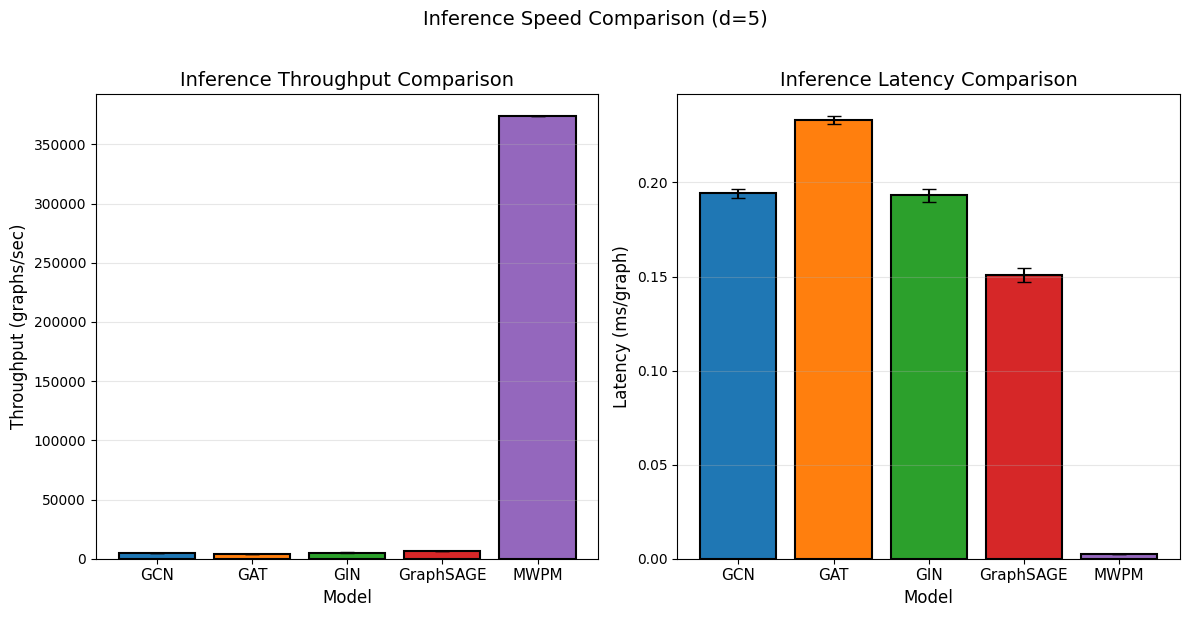

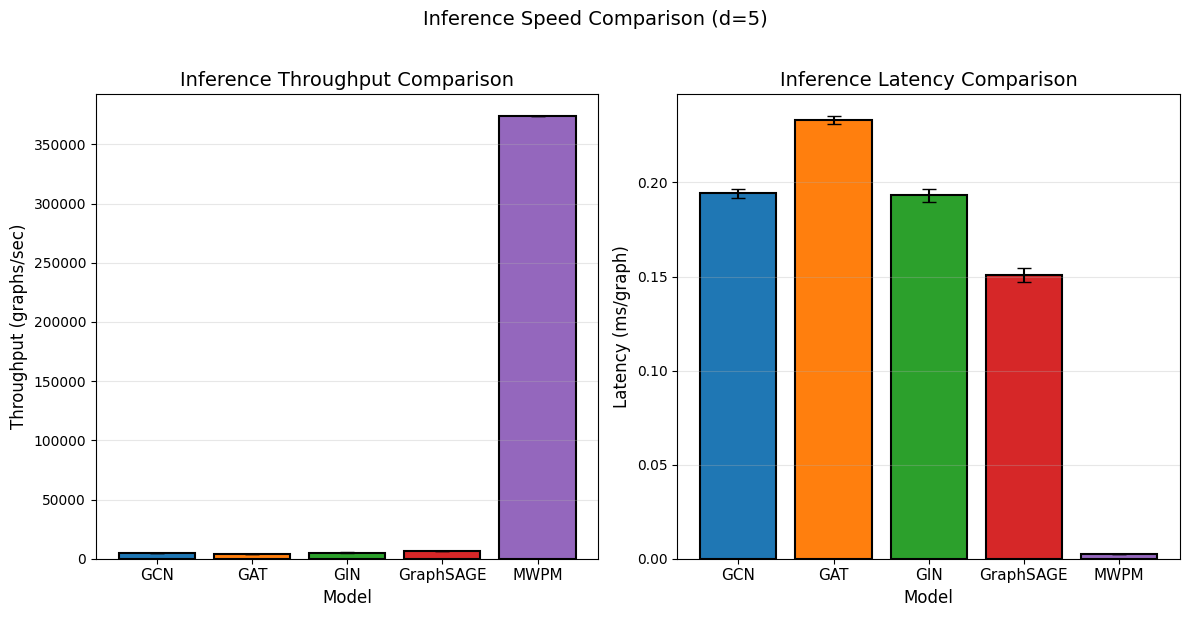

In [73]:
# Plot inference speed comparison
plot_inference_comparison(
    results=speed_results,
    save_path=f"benchmarks/inference_comparison_d{DISTANCE}.png"
)

#### Inference Speed Ranking

Rankings based on inference speed metrics (higher throughput is better):

In [74]:
def print_speed_ranking(speed_results: dict):
    """Print model rankings based on inference speed metrics."""
    print("=" * 70)
    print("MODEL RANKINGS - INFERENCE SPEED COMPARISON")
    print("=" * 70)
    
    # Collect model data including MWPM
    model_data = []
    
    for model_type, results in speed_results['models'].items():
        model_data.append({
            'name': get_model_display_name(model_type),
            'mean_throughput': results['mean_throughput'],
            'std_throughput': results['std_throughput'],
            'mean_latency': results['mean_latency'],
            'std_latency': results['std_latency'],
        })
    
    # Add MWPM
    model_data.append({
        'name': 'MWPM',
        'mean_throughput': speed_results['mwpm']['throughput_graphs_per_sec'],
        'std_throughput': 0.0,
        'mean_latency': speed_results['mwpm']['latency_ms_per_graph'],
        'std_latency': 0.0,
    })
    
    # Sort by throughput (higher is better)
    ranked_by_throughput = sorted(model_data, key=lambda x: x['mean_throughput'], reverse=True)
    
    print("\n🏆 RANKING BY THROUGHPUT (Higher is Better)")
    print("-" * 70)
    print(f"{'Rank':<6} {'Model':<15} {'Throughput (g/s)':<20} {'Std':<15}")
    print("-" * 70)
    for rank, model in enumerate(ranked_by_throughput, 1):
        medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
        print(f"{medal} {rank:<3} {model['name']:<15} {model['mean_throughput']:<20.1f} {model['std_throughput']:.1f}")
    
    # Sort by latency (lower is better)
    ranked_by_latency = sorted(model_data, key=lambda x: x['mean_latency'])
    
    print("\n🏆 RANKING BY LATENCY (Lower is Better)")
    print("-" * 70)
    print(f"{'Rank':<6} {'Model':<15} {'Latency (ms)':<20} {'Std':<15}")
    print("-" * 70)
    for rank, model in enumerate(ranked_by_latency, 1):
        medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
        print(f"{medal} {rank:<3} {model['name']:<15} {model['mean_latency']:<20.6f} {model['std_latency']:.6f}")
    
    print("=" * 70)
    
    return ranked_by_throughput, ranked_by_latency

# Print speed rankings
throughput_ranking, latency_ranking = print_speed_ranking(speed_results)

MODEL RANKINGS - INFERENCE SPEED COMPARISON

🏆 RANKING BY THROUGHPUT (Higher is Better)
----------------------------------------------------------------------
Rank   Model           Throughput (g/s)     Std            
----------------------------------------------------------------------
🥇 1   MWPM            373542.7             0.0
🥈 2   GraphSAGE       6632.1               159.8
🥉 3   GIN             5178.3               94.3
   4   GCN             5148.5               62.9
   5   GAT             4291.1               37.6

🏆 RANKING BY LATENCY (Lower is Better)
----------------------------------------------------------------------
Rank   Model           Latency (ms)         Std            
----------------------------------------------------------------------
🥇 1   MWPM            0.002677             0.000000
🥈 2   GraphSAGE       0.150872             0.003716
🥉 3   GIN             0.193178             0.003492
   4   GCN             0.194261             0.002367
   5   GAT       

### Summary Tables

In [63]:
def print_detailed_summary(accuracy_results: dict, speed_results: dict):
    """Print detailed summary tables of all comparison results."""
    
    print("=" * 80)
    print("DETAILED COMPARISON SUMMARY")
    print("=" * 80)
    
    # Accuracy summary
    print("\n" + "-" * 80)
    print("ACCURACY METRICS (Mean ± Std across seeds)")
    print("-" * 80)
    print(f"{'Model':<12} {'Accuracy':<18} {'LER':<18} {'Precision':<12} {'Recall':<12} {'F1':<12}")
    print("-" * 80)
    
    for model_type, results in accuracy_results['models'].items():
        name = get_model_display_name(model_type)
        acc = f"{results['mean_accuracy']:.4f} ± {results['std_accuracy']:.4f}"
        ler = f"{results['mean_ler']:.4f} ± {results['std_ler']:.4f}"
        
        # Get average precision/recall/f1 from seed results
        precisions = [r['precision'] for r in results['seed_results'].values()]
        recalls = [r['recall'] for r in results['seed_results'].values()]
        f1s = [r['f1'] for r in results['seed_results'].values()]
        
        prec = f"{np.mean(precisions):.4f}"
        rec = f"{np.mean(recalls):.4f}"
        f1 = f"{np.mean(f1s):.4f}"
        
        print(f"{name:<12} {acc:<18} {ler:<18} {prec:<12} {rec:<12} {f1:<12}")
    
    # MWPM row
    mwpm_ler = np.mean(list(accuracy_results['mwpm']['per_p_ler'].values()))
    print(f"{'MWPM':<12} {1-mwpm_ler:.4f}             {mwpm_ler:.4f}             {'N/A':<12} {'N/A':<12} {'N/A':<12}")
    
    # Per-p LER table
    print("\n" + "-" * 80)
    print("LOGICAL ERROR RATE BY PHYSICAL ERROR RATE")
    print("-" * 80)
    
    p_values = accuracy_results['p_values']
    header = f"{'Model':<12} " + " ".join([f"p={p:.3f}" for p in p_values])
    print(header)
    print("-" * 80)
    
    for model_type, results in accuracy_results['models'].items():
        name = get_model_display_name(model_type)
        lers = [f"{results['per_p_mean_ler'].get(p, 0):.4f}" for p in p_values]
        print(f"{name:<12} " + "   ".join(lers))
    
    mwpm_lers = [f"{accuracy_results['mwpm']['per_p_ler'].get(p, 0):.4f}" for p in p_values]
    print(f"{'MWPM':<12} " + "   ".join(mwpm_lers))
    
    # Speed summary
    print("\n" + "-" * 80)
    print("INFERENCE SPEED (Mean ± Std across seeds)")
    print("-" * 80)
    print(f"{'Model':<12} {'Throughput (g/s)':<25} {'Latency (ms)':<20} {'vs MWPM':<15}")
    print("-" * 80)
    
    mwpm_tp = speed_results['mwpm']['throughput_graphs_per_sec']
    
    for model_type, results in speed_results['models'].items():
        name = get_model_display_name(model_type)
        tp = f"{results['mean_throughput']:.1f} ± {results['std_throughput']:.1f}"
        lat = f"{results['mean_latency']:.4f} ± {results['std_latency']:.4f}"
        
        if results['mean_throughput'] > mwpm_tp:
            ratio = f"{results['mean_throughput']/mwpm_tp:.2f}x faster"
        else:
            ratio = f"{mwpm_tp/results['mean_throughput']:.2f}x slower"
        
        print(f"{name:<12} {tp:<25} {lat:<20} {ratio:<15}")
    
    print(f"{'MWPM':<12} {mwpm_tp:<25.1f} {speed_results['mwpm']['latency_ms_per_graph']:<20.4f} {'baseline':<15}")
    print("=" * 80)

# Print the detailed summary
print_detailed_summary(accuracy_results, speed_results)

DETAILED COMPARISON SUMMARY

--------------------------------------------------------------------------------
ACCURACY METRICS (Mean ± Std across seeds)
--------------------------------------------------------------------------------
Model        Accuracy           LER                Precision    Recall       F1          
--------------------------------------------------------------------------------
GCN          0.8377 ± 0.0008    0.1623 ± 0.0008    0.7314       0.3232       0.4477      
GAT          0.9212 ± 0.0048    0.0788 ± 0.0048    0.8422       0.7550       0.7958      
GIN          0.9319 ± 0.0210    0.0681 ± 0.0210    0.8683       0.7824       0.8207      
GraphSAGE    0.9529 ± 0.0009    0.0471 ± 0.0009    0.9074       0.8565       0.8811      
MWPM         0.9832             0.0168             N/A          N/A          N/A         

--------------------------------------------------------------------------------
LOGICAL ERROR RATE BY PHYSICAL ERROR RATE
---------------------

#### Overall Model Ranking

Combined rankings across all evaluation metrics:

In [64]:
def print_overall_ranking(accuracy_results: dict, speed_results: dict):
    """Print comprehensive model rankings across all metrics."""
    print("=" * 80)
    print("OVERALL MODEL RANKINGS - COMPREHENSIVE COMPARISON")
    print("=" * 80)
    
    # Get all model names (excluding MWPM for GNN comparison)
    model_types = list(accuracy_results['models'].keys())
    
    # Calculate rankings for each metric
    rankings = {}
    
    # LER ranking (lower is better)
    ler_data = [(mt, accuracy_results['models'][mt]['mean_ler']) for mt in model_types]
    ler_sorted = sorted(ler_data, key=lambda x: x[1])
    for rank, (mt, _) in enumerate(ler_sorted, 1):
        rankings.setdefault(mt, {})['ler_rank'] = rank
    
    # Accuracy ranking (higher is better)
    acc_data = [(mt, accuracy_results['models'][mt]['mean_accuracy']) for mt in model_types]
    acc_sorted = sorted(acc_data, key=lambda x: x[1], reverse=True)
    for rank, (mt, _) in enumerate(acc_sorted, 1):
        rankings[mt]['acc_rank'] = rank
    
    # Throughput ranking (higher is better)
    tp_data = [(mt, speed_results['models'][mt]['mean_throughput']) for mt in model_types]
    tp_sorted = sorted(tp_data, key=lambda x: x[1], reverse=True)
    for rank, (mt, _) in enumerate(tp_sorted, 1):
        rankings[mt]['tp_rank'] = rank
    
    # Latency ranking (lower is better)
    lat_data = [(mt, speed_results['models'][mt]['mean_latency']) for mt in model_types]
    lat_sorted = sorted(lat_data, key=lambda x: x[1])
    for rank, (mt, _) in enumerate(lat_sorted, 1):
        rankings[mt]['lat_rank'] = rank
    
    # Calculate average rank
    for mt in model_types:
        rankings[mt]['avg_rank'] = np.mean([
            rankings[mt]['ler_rank'],
            rankings[mt]['acc_rank'],
            rankings[mt]['tp_rank'],
            rankings[mt]['lat_rank']
        ])
    
    # Sort by average rank
    overall_ranking = sorted(rankings.items(), key=lambda x: x[1]['avg_rank'])
    
    print("\n🏆 RANKING BY INDIVIDUAL METRICS (GNN Models Only)")
    print("-" * 80)
    print(f"{'Model':<15} {'LER Rank':<12} {'Acc Rank':<12} {'Speed Rank':<12} {'Latency Rank':<12}")
    print("-" * 80)
    
    for mt, ranks in overall_ranking:
        name = get_model_display_name(mt)
        print(f"{name:<15} {ranks['ler_rank']:<12} {ranks['acc_rank']:<12} {ranks['tp_rank']:<12} {ranks['lat_rank']:<12}")
    
    print("\n🏆 OVERALL RANKING (By Average Rank - Lower is Better)")
    print("-" * 80)
    print(f"{'Rank':<6} {'Model':<15} {'Avg Rank':<12} {'Best At':<30}")
    print("-" * 80)
    
    for rank, (mt, ranks) in enumerate(overall_ranking, 1):
        name = get_model_display_name(mt)
        medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
        
        # Find what this model is best at
        best_at = []
        if ranks['ler_rank'] == 1:
            best_at.append("LER")
        if ranks['acc_rank'] == 1:
            best_at.append("Accuracy")
        if ranks['tp_rank'] == 1:
            best_at.append("Speed")
        if ranks['lat_rank'] == 1:
            best_at.append("Latency")
        
        best_str = ", ".join(best_at) if best_at else "-"
        print(f"{medal} {rank:<3} {name:<15} {ranks['avg_rank']:<12.2f} {best_str:<30}")
    
    # Summary comparison with MWPM
    print("\n" + "-" * 80)
    print("COMPARISON WITH MWPM BASELINE")
    print("-" * 80)
    
    mwpm_ler = accuracy_results['mwpm']['overall_ler']
    mwpm_tp = speed_results['mwpm']['throughput_graphs_per_sec']
    
    print(f"{'Model':<15} {'LER vs MWPM':<20} {'Speed vs MWPM':<25} {'Verdict':<20}")
    print("-" * 80)
    
    for mt, _ in overall_ranking:
        name = get_model_display_name(mt)
        model_ler = accuracy_results['models'][mt]['mean_ler']
        model_tp = speed_results['models'][mt]['mean_throughput']
        
        ler_diff = model_ler - mwpm_ler
        ler_str = f"{ler_diff:+.4f}" + (" (better)" if ler_diff < 0 else " (worse)")
        
        speed_ratio = mwpm_tp / model_tp
        speed_str = f"{speed_ratio:.1f}x slower"
        
        if ler_diff < 0:
            verdict = "Better accuracy"
        elif ler_diff > 0.01:
            verdict = "Worse overall"
        else:
            verdict = "Comparable"
        
        print(f"{name:<15} {ler_str:<20} {speed_str:<25} {verdict:<20}")
    
    print("=" * 80)

# Print overall rankings
print_overall_ranking(accuracy_results, speed_results)

OVERALL MODEL RANKINGS - COMPREHENSIVE COMPARISON

🏆 RANKING BY INDIVIDUAL METRICS (GNN Models Only)
--------------------------------------------------------------------------------
Model           LER Rank     Acc Rank     Speed Rank   Latency Rank
--------------------------------------------------------------------------------
GraphSAGE       1            1            1            1           
GIN             2            2            2            2           
GAT             3            3            4            4           
GCN             4            4            3            3           

🏆 OVERALL RANKING (By Average Rank - Lower is Better)
--------------------------------------------------------------------------------
Rank   Model           Avg Rank     Best At                       
--------------------------------------------------------------------------------
🥇 1   GraphSAGE       1.00         LER, Accuracy, Speed, Latency 
🥈 2   GIN             2.00         -           